In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# Step 1: Generate Synthetic Data for 10,000 Customers (₹ INR)
np.random.seed(42)
data = {
    "CustomerID": np.arange(1, 10001),
    "Age": np.random.randint(18, 70, 10000),
    "Gender": np.random.choice(["Male", "Female"], 10000),
    "Annual Income (₹ Lakhs)": np.random.uniform(2, 50, 10000).round(2),  # ₹2L to ₹50L
    "Spending Score (1-100)": np.random.randint(1, 101, 10000),
    "Credit Score": np.random.randint(300, 900, 10000),  # Indian credit score range
    "Online Shopping Frequency": np.random.randint(0, 30, 10000),  # Monthly orders
    "Membership Duration (Years)": np.random.randint(1, 15, 10000),
    "Discount Usage (%)": np.random.randint(0, 100, 10000),
    "Total Transactions": np.random.randint(1, 500, 10000),  # Annual transactions
    "Avg Transaction Value (₹ Thousands)": np.random.uniform(1, 100, 10000).round(2),  # ₹1K to ₹100K
}
df = pd.DataFrame(data)
df.head()

,CustomerID,Age,Gender,Annual Income (₹ Lakhs),Spending Score (1-100),Credit Score,Online Shopping Frequency,Membership Duration (Years),Discount Usage (%),Total Transactions,Avg Transaction Value (₹ Thousands)
0,1,56,Male,8.16,28,492,14,4,61,8,94.14
1,2,69,Female,14.73,67,787,25,10,24,440,8.23
2,3,46,Female,42.09,71,648,15,8,66,98,72.26
3,4,32,Female,17.70,14,388,7,2,37,286,55.34
4,5,60,Male,25.43,79,422,1,9,95,74,95.47


In [5]:
# Step 2: Convert Gender to Numerical (0=Male, 1=Female)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Gender"]

,Gender
0,0
1,1
2,1
3,1
4,0
...,...
9995,0
9996,1
9997,1
9998,0


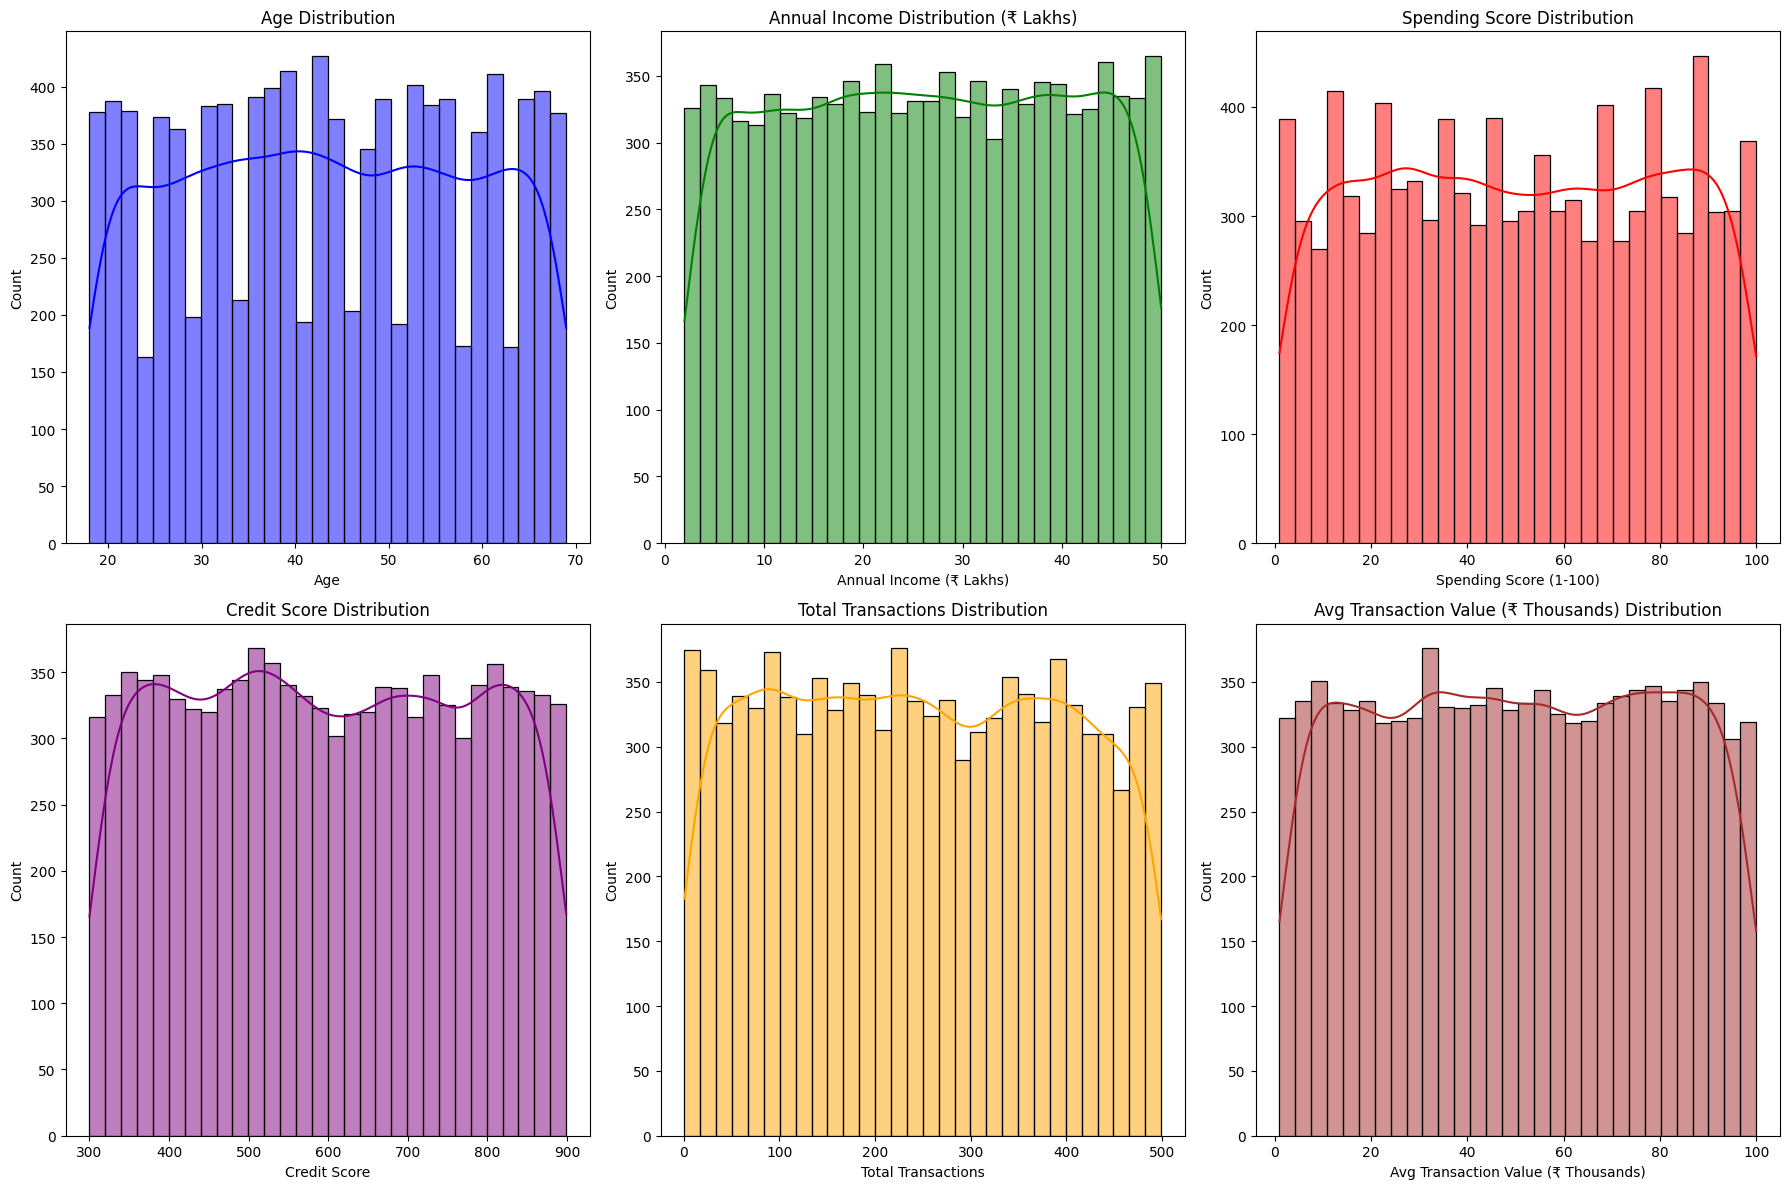

In [6]:
# Step 3: Exploratory Data Analysis (EDA) - Histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.histplot(df["Age"], bins=30, kde=True, color="blue", ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["Annual Income (₹ Lakhs)"], bins=30, kde=True, color="green", ax=axes[0, 1])
axes[0, 1].set_title("Annual Income Distribution (₹ Lakhs)")

sns.histplot(df["Spending Score (1-100)"], bins=30, kde=True, color="red", ax=axes[0, 2])
axes[0, 2].set_title("Spending Score Distribution")

sns.histplot(df["Credit Score"], bins=30, kde=True, color="purple", ax=axes[1, 0])
axes[1, 0].set_title("Credit Score Distribution")

sns.histplot(df["Total Transactions"], bins=30, kde=True, color="orange", ax=axes[1, 1])
axes[1, 1].set_title("Total Transactions Distribution")

sns.histplot(df["Avg Transaction Value (₹ Thousands)"], bins=30, kde=True, color="brown", ax=axes[1, 2])
axes[1, 2].set_title("Avg Transaction Value (₹ Thousands) Distribution")

plt.tight_layout()
plt.show()

In [7]:
df.columns[1:]

Index(['Age', 'Gender', 'Annual Income (₹ Lakhs)', 'Spending Score (1-100)',
       'Credit Score', 'Online Shopping Frequency',
       'Membership Duration (Years)', 'Discount Usage (%)',
       'Total Transactions', 'Avg Transaction Value (₹ Thousands)'],
      dtype='object')

In [8]:
# Step 4: Feature Selection & Scaling
features = df.columns[1:]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [9]:
# Step 5: Elbow Method to Find Optimal K
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

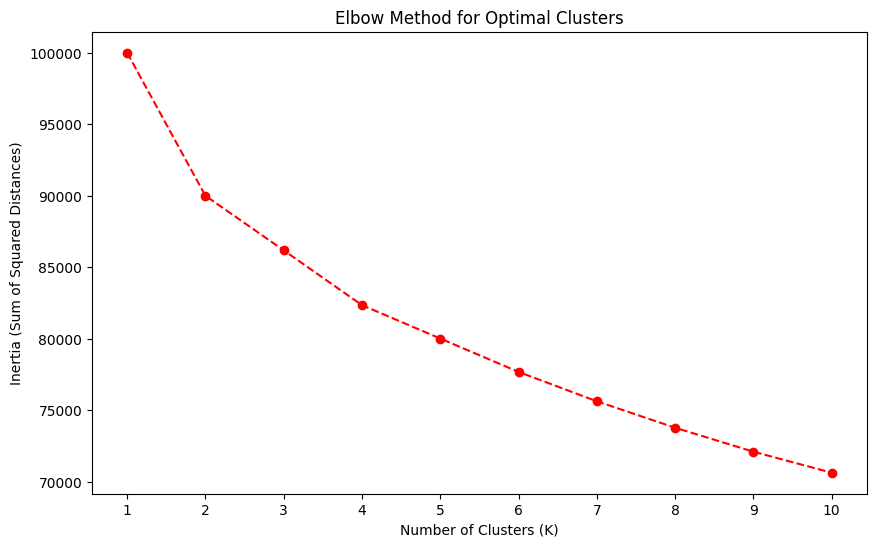

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker="o", linestyle="--", color="red")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

In [11]:
# Step 6: Apply K-Means Clustering (Assume Best K=5 from Elbow Method)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

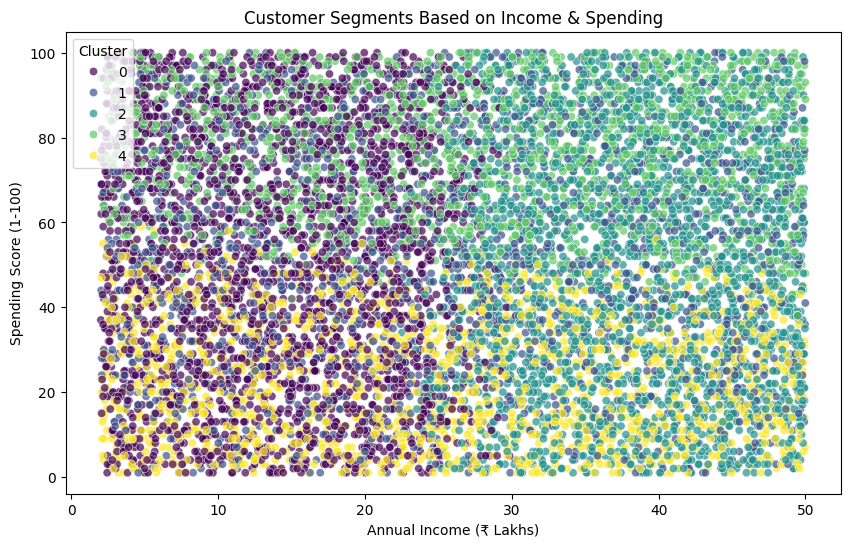

In [12]:
# Step 7: Visualizing Clusters (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Annual Income (₹ Lakhs)"], y=df["Spending Score (1-100)"], hue=df["Cluster"], palette="viridis", alpha=0.7)
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments Based on Income & Spending")
plt.legend(title="Cluster")
plt.show()

In [13]:
# Step 8: Cluster Insights
print(df.groupby("Cluster").mean()[["Age", "Annual Income (₹ Lakhs)", "Spending Score (1-100)", "Avg Transaction Value (₹ Thousands)"]])

               Age  Annual Income (₹ Lakhs)  Spending Score (1-100)  \
Cluster                                                               
0        43.144409                14.234381               50.765889   
1        42.681944                25.423644               51.960243   
2        43.861740                38.264537               49.820818   
3        43.973602                27.470434               76.942803   
4        44.186834                25.401060               23.394357   

         Avg Transaction Value (₹ Thousands)  
Cluster                                       
0                                  50.135817  
1                                  52.089177  
2                                  50.038121  
3                                  48.665280  
4                                  51.666746  


In [ ]:
# the end

In [ ]:
# project2:

In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [16]:
# Generate synthetic data (100 customers, ₹ INR)
np.random.seed(42)
df = pd.DataFrame({
    "CustomerID": np.arange(1, 101),
    "Age": np.random.randint(18, 70, 100),
    "Annual Income (₹ Lakhs)": np.random.uniform(2, 50, 100).round(2),
    "Spending Score (1-100)": np.random.randint(1, 101, 100),
})
df.head()

,CustomerID,Age,Annual Income (₹ Lakhs),Spending Score (1-100)
0,1,56,9.93,80
1,2,69,2.75,93
2,3,46,22.32,3
3,4,32,20.95,20
4,5,60,16.09,59


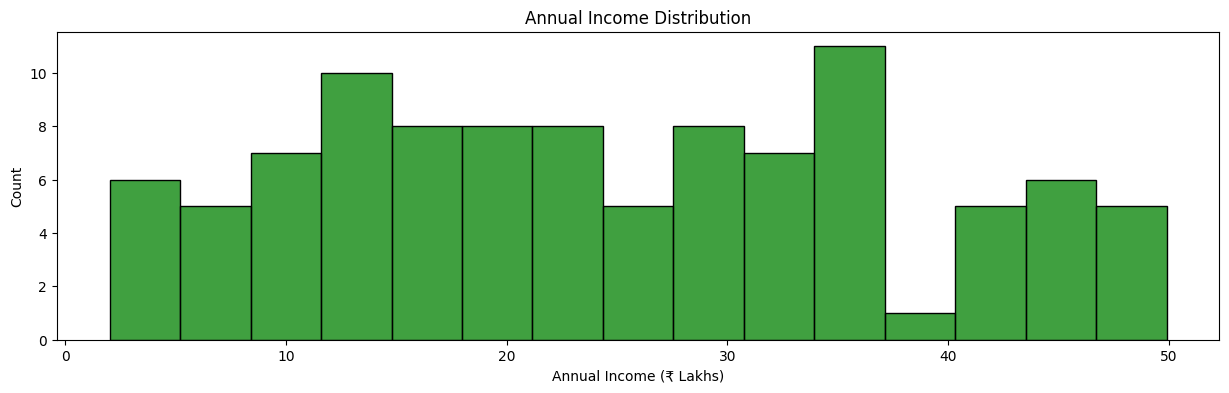

In [17]:
# Visualizing Data Distribution
plt.figure(figsize=(15, 4))
sns.histplot(df["Annual Income (₹ Lakhs)"], bins=15, kde=False, color="green")
plt.title("Annual Income Distribution")
plt.show()

In [18]:
# Scaling Data for Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["Age", "Annual Income (₹ Lakhs)", "Spending Score (1-100)"]])

In [19]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Annual Income (₹ Lakhs),0
Spending Score (1-100),0


In [20]:
# Finding Optimal Clusters (Elbow Method)
inertia = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

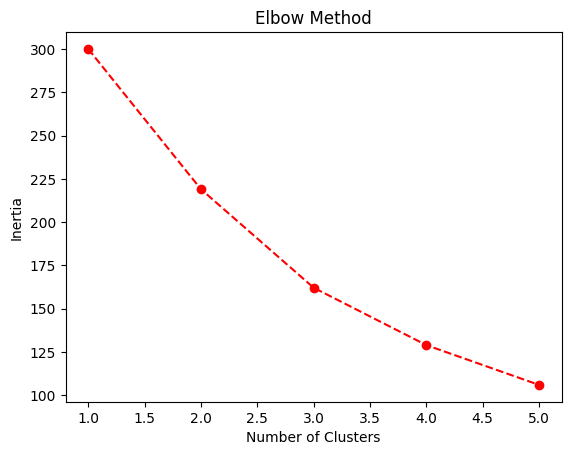

In [21]:
plt.plot(range(1, 6), inertia, marker="o", linestyle="--", color="red")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
# Applying K-Means (Assuming Best K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

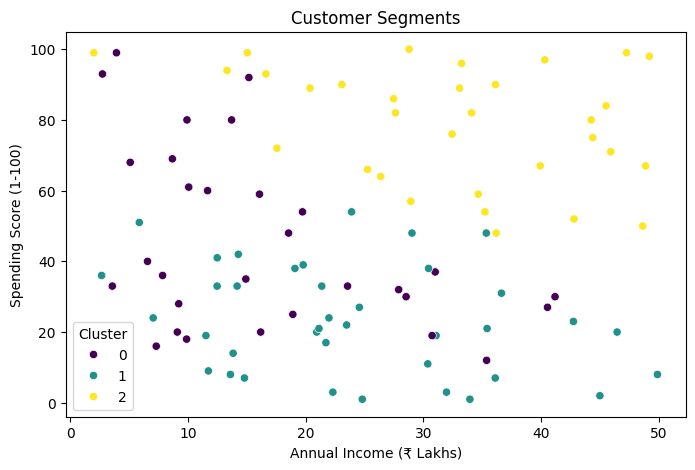

In [23]:
# Scatter Plot: Annual Income vs Spending Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Annual Income (₹ Lakhs)"], y=df["Spending Score (1-100)"], hue=df["Cluster"], palette="viridis")
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.legend(title="Cluster")
plt.show()

In [24]:
# Display Cluster Averages
print(df.groupby("Cluster")[["Age", "Annual Income (₹ Lakhs)", "Spending Score (1-100)"]].mean())

               Age  Annual Income (₹ Lakhs)  Spending Score (1-100)
Cluster                                                            
0        59.500000                16.600333               45.133333
1        33.421053                24.062368               23.578947
2        40.000000                32.651875               78.906250


In [ ]:
Business Insights
🔹 Cluster 0: High income, moderate spending – Targeted promotions
🔹 Cluster 1: Young, high spenders – Premium offers
🔹 Cluster 2: Older, low spenders – Engagement campaigns

# THE END